# User Manual

`ethograph` is a GUI for visualizing and segmenting multimodal behavioural
recordings.

## Install

```bash
uv tool install --python 3.12 "ethograph[gui,audio]"
```

Launch with `ethograph launch`, or the desktop shortcut. See
{doc}`installation` for detailed  instructions and troubleshooting.

## Multimodal visualization

Ethograph allows you to visualize a number of different data modalities:

| Data | Shown as | File formats / loaders |
|------|----------|------------------------|
| **Video** | multi-panel video | `.mp4`, `.avi`, `.mov`, `.mkv` (via [pyav](https://pyav.org/docs/stable/) and [pynaviz](https://pynapple-org.github.io/pynaviz)) |
| **Pose / BoundingBox** | Overlay on video | `.h5`, `.csv`, `.slp` (DLC, SLEAP, LightningPose, ... via [movement](https://movement.neuroinformatics.dev)) |
| **Audio** | Waveform + spectrogram | `.wav`, `.flac`, `.ogg`, `.mp3` (via [audioio](https://github.com/bendalab/audioio)) |
| **Electrophysiology** | Multi-channel trace | `.dat`, `.bin`, `.raw` via [phylib](https://github.com/cortex-lab/phylib), and {ref}`many more formats <target-ephys-formats>` via [Neo](https://neo.readthedocs.io) |
| **Spike-sorted units** | Raster / PSTH | [Kilosort](https://github.com/MouseLand/Kilosort) folder, `.nwb` file, {class}`pynapple.TsGroup` |
| **Features** | Line plots / heatmaps | Kinematics, firing rates, latent variables, model outputs, etc. |

Feature data can be loaded via three backends:
| Backend | Object | File format |
|---------|--------|-------------|
| **xarray** | {class}`xarray.Dataset` / {class}`~ethograph.io.trialtree.TrialTree` | `.nc` |
| **Pynapple** | {class}`~pynapple.Tsd` / {class}`~pynapple.TsdFrame` | `.npz` or folder |
| **NWB** | `.nwb` (loaded via {mod}`pynapple`) | `.nwb` |
| **numpy** | plain array | `.npy` |

Unlike a plain numpy array, the top three formats carry explicit timestamps with
each value. This allows `ethograph` to automatically align data of different
sampling rates and modalities (video, audio & electrophysiology).

```{note}
`.npy` only supports `(T, D)` dimensional data. It can be loaded via drag & drop, you'll be asked for the sampling
rate of each timestamp (T), and it is converted internally into a timestamped object.
```

(target-data-loading)=
## Loading your data

Launching opens the start page. It lists the supported file types along the
bottom and offers three ways in:

![The Ethograph start page](../_static/media/cover_page.png)

### Which entry point?

New here? Start with **Template datasets** (1) — example data of cool animal
behaviours (🐦‍⬛🐦🎶🦗🐀) that loads in one click. See more here:
{ref}`examples gallery <target-examples-gallery>`.

For your own data, the question is not how many files you have — drag & drop
takes many — but how they are arranged across devices and trials.

| Your data | Use |
|---|---|
| **One trial, many devices.** Files that start together and cover the same stretch of time — four cameras, three microphones, pose per camera. | **Drag & drop** (2), *Several cameras/mics filming one trial* |
| **Many trials, one device.** One file per trial per stream — `trial001.mp4, trial002.mp4, …`, optionally with matching pose and audio files. | **Drag & drop** (2), *Several trials of one device* |
| **Many trials *and* many devices** — e.g. 20 trials filmed by 2 cameras with 1 microphone (40 videos + 20 audio files); **streams needing offsets** — ephys on its own clock, trial windows carved out of a continuous recording; or an **existing session file** (`.nc` with trials, `.nwb`, pynapple). | **Custom set-up** (3) |


### Drag & drop

Pick a layout in the drop card's dropdown, drop the files, click **Load**.
Frame rates, sample rates and durations are read from the files themselves.
You are only asked for what cannot be inferred: the source software of an
ambiguous `.h5`/`.csv` pose file, the sampling rate of a `.npy`, or the camera
order when several videos and pose files arrive together.

**Several cameras/mics filming one trial** (default): several videos become
`cam-1`, `cam-2`, … (each its own view, one shared playhead); several audio
files become `mic-1`, `mic-2`, … A multichannel `.wav` is split into channels
automatically.

**Several trials of one device**: the files of each stream are natural-sorted
and paired one per trial, so `trial001.mp4` goes with `trial001.h5`. Every
stream must hold the same number of files; the result is a multi-trial session
you navigate trial by trial.

In both layouts, pose files also gain velocity, acceleration and speed per
keypoint on load.

#### Project folder — keep your drops

A drop is a quick look by default: the alignment it builds lives in a temp
folder and is gone next time. Choose a **Project folder** in the bar above the
cards to keep them instead. Every drop made while it is set lands in the
project's `sessions/` folder, one timestamped folder per drop (`2026-09-06_21-47-12/`),
holding the alignment file, anything derived from the drop and the panel
layout you left it with. The drop card then lists them under **Reopen a previous
drop…**: pick one, click **Load**, and the session comes back as it was. Your
media and data files stay where they are — nothing is copied into the project.

### Custom set-up

Point the loader at a session file (`.nc`, `.nwb`, `.npz` or a pynapple folder)
plus, optionally, the folders holding your media. Ephys recorded on its own
clock gets an **Ephys offset (s)** field here.

The I/O section offers a lot of flexibility, but may be overly complex for your
data. In many cases the **Data wizard** button can guide you through organizing
and temporally aligning your media streams — including many trials across
several cameras and microphones — into a `session.nc`. For more complex
scenarios you may have to write a custom Python script:

See {doc}`your_data/index` for the full workflow and dataset schema, and
{doc}`your_data/ephys` for ephys formats and Kilosort.


## Labelling

Ethograph is a labelling GUI for marking the onset and offset of behavioural
events. Press a number key to select a label class, click on the timeseries plot to
mark the onset, click again to mark the offset, then press **V** to play back
the segment you just labelled.

<div style="padding:48.25% 0 0 0;position:relative;"><iframe src="https://player.vimeo.com/video/1212440885?badge=0&amp;autopause=0&amp;player_id=0&amp;app_id=58479" frameborder="0" allow="autoplay; fullscreen; picture-in-picture; clipboard-write; encrypted-media; web-share" referrerpolicy="strict-origin-when-cross-origin" style="position:absolute;top:0;left:0;width:100%;height:100%;" title="ethograph_label_basic"></iframe></div><script src="https://player.vimeo.com/api/player.js"></script>


The {doc}`labels <../advanced/labels/index>` documentation includes more info on how to:

- label in the GUI
- define new label categories (`mapping.txt`)
- deal with labels overlapping in time (label branches)
- import labels from other formats (Pynapple, NWB, BORIS, audacity, Raven, ...)
- export labels 


(target-user-manual-metadata)=
## Trial metadata

Per-trial conditions (stimulus, reward, pellet count, ...) live in a small
table — a `{stem}_metadata.tsv` next to your data, or the NWB trials table —
and show up as the **trials table** at the top of the Navigation section,
where each column becomes a filter. See {doc}`../advanced/metadata`.

```{important}
**The trials table is the one place trials are included or excluded — and it
applies to everything.** Filter `num_pellets` to `1, 2` (not `0`) and every
operation sees only those trials: navigation, label/sequence jumps,
changepoint correction, curation (Ctrl+C, inspect mode, frame-by-frame
review, the label and video grids), model **training** and model
**inference**. A label in a filtered-out trial is not visited, curated,
trained on or predicted over until you widen the filter. No dialog has a
trial filter of its own; each one tells you how many trials it will run over.
```

Two more things worth knowing: Ethograph keeps a `curated` column in that
table itself (`yes` once every label of a trial is manual or curated, otherwise `no` — see
{doc}`../models/curation`), and metadata edits save on their own,
about a second after you stop typing — `Ctrl+S` is only for labels.


## The interface

The layout is **responsive and panel-based**: every plot, video and trace lives
in its own panel that you can drag, stack, tab, float and resize freely.

- **Click a panel to edit it.** The right sidebar is context-sensitive — clicking
  a panel shows the settings for *that* panel (e.g. the feature and its
  dimensions for a line plot, or the channel for an audio panel).
- **Add panels with the ➕ Add panel button** (bottom-left of the window, or
  `Shift+N`): drag a data source onto the plot area, or press Enter to drop it in
  the default spot. Remove any panel with its ✕. You can open as many as you
  like — e.g. the same feature as both a line plot and a heatmap.

### Which individual a panel shows

With more than one individual in the dataset, every panel is in one of two
modes, shown in its title:

```
speed — bird_1 (sidebar)    follows the Individual combo
speed — bird_2 (pinned)     ignores it
```

- **The Individual combo** sets what every `(sidebar)` panel shows, and the
  default for new panels.
- **📌** next to the combo pins the last clicked panel — any panel — to one
  individual, or sets it back to *Follow sidebar*. The same entries end a
  panel's ⠿ menu.
- A pinned panel shows and creates only that individual's labels. If its data
  has an individual dimension, the pin selects that individual's data too (a
  space or radial plot's own **Individual** combo *is* its pin).

To compare two birds side by side: add two duplicate lineplots via 
➕ Add panel. Then for one of them, click 📌 → `bird_2`. Switching the combo 
now moves only the original.

## Video & audio playback

Two things are easy to miss when you first play back a recording:

- **The red timeline marker tracks exact time, not the video frame.** Video is
  discrete frames, but audio and other signals have far finer resolution, so
  clicking a plot places the marker (and any label) at the exact time you
  clicked — the video just seeks to the nearest frame as a visual reference.
- **Only "Audio-synced" playback plays sound.** The playback mode dropdown in
  the bottom bar also offers silent "Smooth" and "Real-time" modes; pick
  Audio-synced whenever you need to hear the audio locked to the video.

See {doc}`../advanced/playback` for the full details, including playback
speed/pitch, video proxies for smooth scrubbing, and which audio channel
Play uses.

## Feature dropdowns

To showcase some `ethograph` functionalities, we will use pose data from a carrion crow performing a tool-use task {cite:p}`moll2025crows`. The {class}`xarray.Dataset` is from one behavioural trial, and shows position, velocity, speed, and acceleration for 3 keypoints tracked in 3D.




In [1]:
import ethograph as eto

ds = eto.sample_data()
ds[["position", "velocity", "speed"]]

<xarray.Dataset> Size: 190kB
Dimensions:     (time: 1077, space: 3, keypoint: 3, individual: 1)
Coordinates:
  * time        (time) float64 9kB 0.0 0.005 0.01 0.015 ... 5.37 5.375 5.38
  * space       (space) <U1 12B 'x' 'y' 'z'
  * keypoint    (keypoint) <U8 96B 'beakTip' 'stickTip' 'pellet'
  * individual  (individual) <U5 20B 'Crow1'
Data variables:
    position    (time, space, keypoint, individual) float64 78kB ...
    velocity    (time, space, keypoint, individual) float64 78kB ...
    speed       (time, keypoint, individual) float64 26kB ...
Attributes:
    source_software:  DeepLabCut
    ds_type:          poses
    fps:              200.0
    time_unit:        seconds
    source_file:      c:/Users/aksel/Documents/Code/ethograph/data/Moll2025/2...
    trial:            41
    pellet_position:  right

<br>
<br>
Notice the dimensions:

| Feature | Dimensions |
|---------|------------|
| `position` | `(time, space, keypoint, individual)` |
| `velocity` | `(time, space, keypoint, individual)` |
| `speed` | `(time, keypoint, individual)` |


<br>
<br>

With {class}`xarray.DataArray`, you can use {meth}`~xarray.DataArray.sel` to pick
a specific keypoint, spatial axis, and individual:

In [3]:
# Standard xarray .sel — works when all dimensions exist
print(f"Dims: {ds['position'].dims}, Shape: {ds['position'].shape}")
beak_x = ds["position"].sel(keypoint="beakTip", space="x", individual="Crow1")
print(f"Dims: {beak_x.dims}, Shape: {beak_x.shape}")

Dims: ('time', 'space', 'keypoint', 'individual'), Shape: (1077, 3, 3, 1)
Dims: ('time',), Shape: (1077,)


<br>

---

<br>

In the GUI, you can switch between features using the **Feature** dropdown and **select** ({meth}`~xarray.DataArray.sel`) a unique combination of feature dimensions. In the video below, the user switches from the feature `speed` to `velocity`, with the selection dimensions `individual=crow1`, `keypoint=beakTip` and `space=["x", "y", "z"]` (All checkbox ticked). Thanks to {func}`~ethograph.sel_valid`, any invalid dimensions are ignored (e.g. it's not problematic that speed does not have a `space` dimension).


<div style="padding:57.64% 0 0 0;position:relative;"><iframe src="https://player.vimeo.com/video/1212439026?badge=0&amp;autopause=0&amp;player_id=0&amp;app_id=58479&amp;loop=1" frameborder="0" allow="autoplay; fullscreen; picture-in-picture; clipboard-write; encrypted-media; web-share" referrerpolicy="strict-origin-when-cross-origin" style="position:absolute;top:0;left:0;width:100%;height:100%;" title="ethograph_feature_dropdowns"></iframe></div><script src="https://player.vimeo.com/api/player.js"></script>


<br>
<br>

At the end of the video and in the plot below, one can see that particularly `velocity` for `keypoint=beakTip` and `space=z` (green line) defines segmentation boundaries of the crows downward movement, inserting the stick tool into the dispenser.

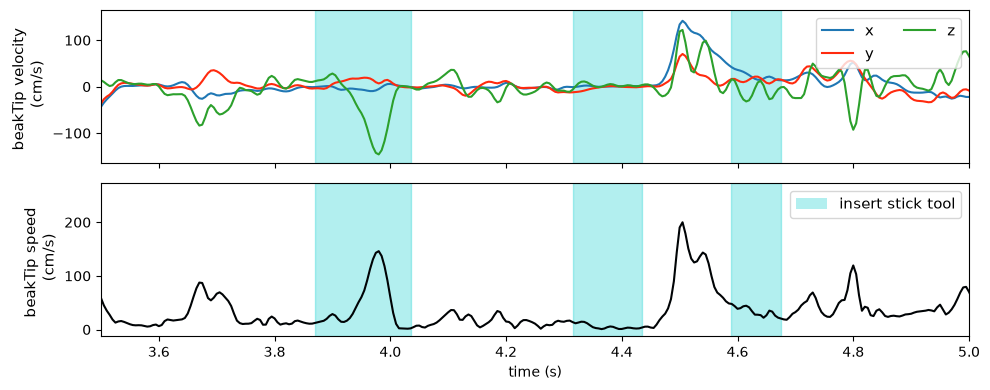

In [4]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

from ethograph.labels.intervals import add_interval, empty_intervals
from ethograph.labels.plots import plot_label_segments

sel = {"keypoint": "beakTip", "individual": "Crow1"}

# 3 labelled intervals (real onsets from the Moll2025 dataset)
label_color = np.array([0, 204, 204]) / 255.0  # _LABEL_COLORS[10]
labels_df = empty_intervals()
labels_df = add_interval(labels_df, 3.87, 4.035, 10, "Crow1")
labels_df = add_interval(labels_df, 4.315, 4.435, 10, "Crow1")
labels_df = add_interval(labels_df, 4.588757756, 4.674700055, 10, "Crow1")

label_mappings = {10: {"name": "stickInDisp", "color": label_color, "order": 10, "branch": 0}}

fig, axes = plt.subplots(2, 1, figsize=(10, 4), sharex=True)

# velocity x, y, z
for i, (axis_name, color) in enumerate(zip(["x", "y", "z"], ["#1f77b4", "#ff2a0e", "#2ca02c"])):
    vel, _ = eto.sel_valid(ds["velocity"].sel(space=axis_name), sel)
    axes[0].plot(ds.time, vel, color=color, label=axis_name)
axes[0].set_ylabel("beakTip velocity \n (cm/s)", fontsize=11)
axes[0].legend(loc="upper right", fontsize=11, ncol=2)
plot_label_segments(axes[0], labels_df, label_mappings, individual="Crow1", is_main=True, alpha=0.3)

# speed
spd, _ = eto.sel_valid(ds["speed"], sel)
axes[1].plot(ds.time, spd, color="#000305")
axes[1].set_ylabel("beakTip speed \n (cm/s)", fontsize=11)
plot_label_segments(axes[1], labels_df, label_mappings, individual="Crow1", is_main=True, alpha=0.3)

axes[1].set_xlabel("time (s)")
insert_stick_patch = mpatches.Patch(
    facecolor=label_color,
    alpha=0.3,
    edgecolor="none",
    label="insert stick tool",
)

handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(
    [insert_stick_patch],
    ["insert stick tool"],
    loc="upper right",
    fontsize=11,
    ncol=4,
)

for ax in axes:
    ax.set_xlim(3.5, 5.0)


plt.tight_layout()
plt.show()

## Changepoints

Besides looking at the `z-velocity`, one can also identify good candidates for segmentation boundaries by looking at where there are minima or turning points in the `beakTip` speed curve. We call these kinematic {doc}`changepoints <../advanced/changepoints/index>`.


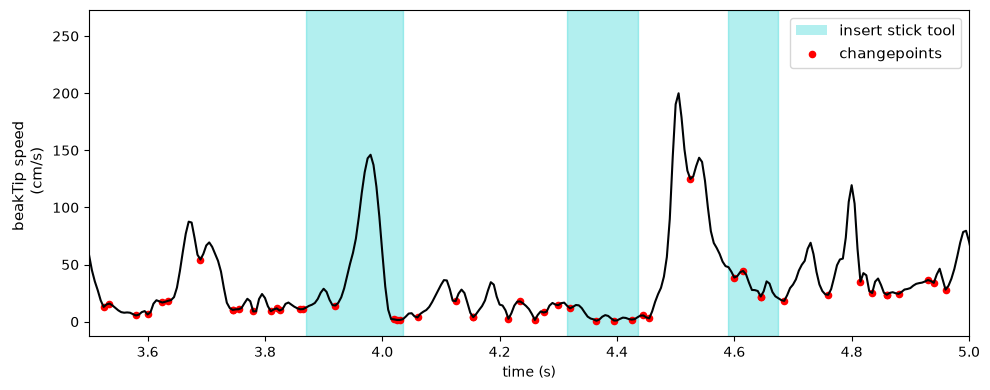

In [6]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np

from ethograph.labels.intervals import add_interval, empty_intervals
from ethograph.labels.plots import plot_label_segments

sel = {"keypoint": "beakTip", "individual": "Crow1"}

# 3 labelled intervals (real onsets from the Moll2025 dataset)
label_color = np.array([0, 204, 204]) / 255.0  # _LABEL_COLORS[10]
labels_df = empty_intervals()
labels_df = add_interval(labels_df, 3.87, 4.035, 10, "Crow1")
labels_df = add_interval(labels_df, 4.315, 4.435, 10, "Crow1")
labels_df = add_interval(labels_df, 4.588757756, 4.674700055, 10, "Crow1")

label_mappings = {10: {"name": "stickInDisp", "color": label_color, "order": 10, "branch": 0}}

fig = plt.subplots(1, 1, figsize=(10, 4), sharex=True)

# speed
spd, _ = eto.sel_valid(ds["speed"], sel)
plt.plot(ds.time, spd, color="#000305")

troughs = ds["speed_troughs"].sel(keypoint="beakTip", individual="Crow1").values
trough_idx = np.where(troughs == 1)[0]
turning_points = ds["speed_turning_points"].sel(keypoint="beakTip", individual="Crow1").values
turning_points_idx = np.where(turning_points == 1)[0]
changepoints_idx = np.sort(np.concatenate([trough_idx, turning_points_idx]))
plt.scatter(ds.time[changepoints_idx], spd[changepoints_idx], s=20, c="r", label="changepoints")
plt.ylabel("beakTip speed \n (cm/s)", fontsize=11)
plot_label_segments(plt, labels_df, label_mappings, individual="Crow1", is_main=True, alpha=0.3)

plt.xlabel("time (s)")
insert_stick_patch = mpatches.Patch(
    facecolor=label_color,
    alpha=0.3,
    edgecolor="none",
    label="insert stick tool",
)

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    [insert_stick_patch, *handles],
    ["insert stick tool", *labels],
    loc="upper right",
    fontsize=11,
)

plt.xlim(3.5, 5.0)
plt.tight_layout()
plt.show()

## Storing trials: Dataset vs TrialTree

Back at the start we split loading into {ref}`one recording versus trials
<target-data-loading>`. That choice decides how you *load*; this section shows
what it looks like on *disk* for the xarray backend. A `session.nc` can hold
either shape, and the GUI accepts both.

**Plain Dataset** — a single `xr.Dataset` saved with
{func}`xarray.Dataset.to_netcdf`. Loaded as one trial:

```python
import xarray as xr

ds = xr.Dataset(...)
ds.to_netcdf("session.nc")
# -> GUI loads this as one trial
```

**TrialTree** — wraps one `xr.Dataset` per trial into a single `.nc`, and is
how multi-trial data is stored on the xarray side (pynapple uses an
{class}`~pynapple.IntervalSet`; NWB uses its `nwb.trials` table):

```python
import ethograph as eto

# Multiple trials: one Dataset per trial
dt = eto.from_datasets([ds_trial1, ds_trial2, ds_trial3])
dt.save("session.nc")

# Access individual trials
ds = dt.trial(1)      # by ID
ds = dt.itrial(0)     # by index
```

**One session-long `xr.Dataset` plus trial start/stop times?** Pass both to
{ref}`from_continuous() <target-from-continuous>`. The times can be a
`pd.DataFrame` with `trial`, `start_time` and `stop_time` columns (in seconds, on
the dataset's time axis) or a {class}`pynapple.IntervalSet`. Each trial becomes
its own window, with time starting at 0:

```python
trials = pd.DataFrame({"trial": [1, 2], "start_time": [0.0, 120.0], "stop_time": [100.0, 250.0]})
dt = eto.from_continuous(ds, trials)
dt.save("session.nc")
```

Storing trials is only half the job: the GUI also needs to know which video,
audio and pose files belong to each trial, which lives in a separate alignment
file. {doc}`your_data/index` covers both ends — the dataset schema and the
alignment — and {doc}`../api/trialtree` documents the full TrialTree API.

If a model will learn from your trials, see {doc}`../models/trial_windows` for
how long to make them.


(target-templates)=
## Template datasets

Ready-made datasets with video, features and labels already in place, downloaded
from the start page. The notebooks that built them are in the
{ref}`examples gallery <target-examples-gallery>`.

**Tool-using crows** {cite:p}`moll2025crows` — Learned precision tool use in carrion crows. Two trials with video, 3D pose (DeepLabCut), kinematics, and video features.

**Lockbox** {cite:p}`reiske2026lockbox` — Behaviour recognition for mice solving mechanical puzzle lockboxes. Six trials with multi-camera video and pose.

**Zebra finches in BirdPark** {cite:p}`ruttimann2025birdpark` — Multimodal dataset of zebra finch groups with synchronized video, microphone arrays, and backpack-mounted accelerometers.

**Cricket stridulation** — Sound production in *Pholidoptera littoralis* with synchronized video, audio, and DeepLabCut pose.
